## Problems Notebook

### Problem 1: Extending the Lady Tasting Tea.

> Let's extend the Lady Tasting Tea experiment as follows. The original experiment has 8 cups: 4 tea-first and 4 milk-first. Suppose we prepare 12 cups: 8 tea-first and 4 milk-first. A participant claims they can tell which was poured first.<br><br>
>Simulate this experiment using numpy by randomly shuffling the cups many times and calculating the probability of the participant correctly identifying all cups by chance. Compare your result with the original 8-cup experiment.<br><br>
>In your notebook, explain your simulation process clearly, report and interpret the estimated probability, and discuss whether, based on this probability, you would consider extending or relaxing the p-value threshold compared to the original design.



#### Lady tasting tea - The background

The lady tasting tea is a famous statistical experiment devised by [Ronald A. Fisher](https://en.wikipedia.org/wiki/Ronald_Fisher) to investigate Dr. Muriel Bristol's claim that she could distinguish between tea with milk poured in first versus milk added after the tea.

In the original experiment eight cups of tea were presented to the lady - four with milk first and four with tea first. They were identical in all other respects and were presented in a _random_ order. Fisher aimed to calculate the probability, _p_ that the lady was selecting the four milk first cups purely by chance.

#### Hypothesis testing

While undertaking this experiment, Fisher introduced the null hypothesis, _H<sub>0</sub>_ and the alternative hypothesis,  _H<sub>a</sub>_. The null hypothesis is the default position where variables do not have a relation with each other. That means the null hypothesis is assumed true until evidence indicates otherwise. 

The alternative hypothesis opposes the null hypothesis and assumes a relationship between the variables and serves as evidence to reject the null hypothesis [geeksforgeeks.org](https://www.geeksforgeeks.org/maths/alternative-hypothesis-definition-types-and-examples/). 

The null and alternative hypotheses are designed to be both exhaustive and mutually exclusive: together they encompass all possible outcomes of an experiment, yet only one of them can hold true in reality.

For this experiment the null hypothesis and the alternative hypothesis are as follows:

>__Null Hypothesis _H<sub>0</sub>_:__
>
>* The lady has no special powers to tell the difference between cups of tea with milk in first and cups of tea with tea in first.
>* The lady is selecting the four cups from eight at random.
>
>__Alternative Hypothesis _H<sub>a</sub>_:__
>* The lady can tell the difference. 

In [70]:
# Mathematical functions from the standard library.
# https://docs.python.org/3/library/math.html
import math

# Permutations and combinations.
# https://docs.python.org/3/library/itertools.html
import itertools

# Random selections.
# https://docs.python.org/3/library/random.html
import random

# Numerical structures and operations.
# https://numpy.org/doc/stable/reference/index.html#reference
import numpy as np

# Plotting.
# https://matplotlib.org/stable/contents.html
import matplotlib.pyplot as plt

# LaTeX rendering. This is optional, but it make the output prettier. We use it to render mathematical expressions.
# https://pypi.org/project/latex/
# You may need to install a LaTeX distribution on your system for this to work.
import latex # pip install latex

# For displaying LaTeX in Jupyter notebooks.
from IPython.display import display, Math, Latex


#### Simulation of the Extended Lady Tasting Tea Experiment

##### Simulation Process

To estimate the probability that a participant could correctly identify all 4 milk-first cups by chance, we simulated the following process:

1. **Label the Cups:** There are 12 cups in total, 4 of which are milk-first and 8 are tea-first. We label them from 1 to 12.
2. **Random Selection:** Randomly select 4 out of the 12 cups to be milk-first (the rest are tea-first).
3. **Simulate Guessing:** The participant guesses which 4 cups are milk-first. Under the null hypothesis (pure guessing), this is equivalent to randomly choosing 4 cups out of 12.
4. **Calculate Success:** A "success" occurs if the participant's guess matches exactly the true set of milk-first cups.
5. **Repeat:** Repeat steps 2–4 many times (e.g., 100,000 or 1,000,000) to estimate the probability of a perfect guess.

Alternatively, we can use combinatorics for the exact probability:


#### Cups of Tea

In [71]:
# Number of cups of tea in total.
no_cups = 12

# Number of cups of tea with milk in first.
no_cups_milk_first = 4

# Number of cups of tea with tea in first.
no_cups_tea_first = 8

#### Combinations of choosing 4 cups from 12

Use [math.comb(n, k)](https://docs.python.org/3/library/math.html#math.comb) to calculate the number of ways of choosing `k` elements from a set of size `n`, where the order of the chosen elements does not matter, and every element can only be selected once.

We are only interested in 4 cups from 12 as if the lady can tell which 4 cups were milk first, it follows that she could also tell which 8 cups were tea first

While using `math.comb(n,k)` it should be noted that both `n` and `k` must be _non-negative integers_ (whole numbers), and can include _0_, so they are not restricted to natural numbers (which start from 1).  The function will raise a 'ValueError' if either `n` or `k` is negative or not an integer.  Additionally, `k` cannot be greater than `n`.

In our case, we use this function to calculate the number of ways to select 4 milk-first cups from a total of 12 cups.

In [72]:

# math.comb(n,k) gives the number of ways of choosing k elements from a set of size n, where the order of the chosen elements does not matter, 
# and every element can only be selected once.                                     
no_ways = math.comb(no_cups, no_cups_milk_first)

no_ways

495


#### How Does `math.comb(n, k)` Work?

The formula for `math.comb(n, k)` is:

$\binom{n}{k} = \frac{n!}{k!(n-k)!}$.

In our experiment:
- \( n = 12 \): total number of cups  
- \( k = 4 \): number of cups which have milk first

Breaking down the calculation:
- \( n! = 12! \) = `12*11*10*9*8*7*6*5*4*3*2*1 = `
- \( k! = 4! \) = `4*3*2*11 = `
- \( (n-k)! = (12 - 4)! = 8! \) = `8*7*6*5*4*3*2*1 = `

Substituting the values:

$\binom{12}{4} = \frac{12!}{4!(8)!} = 495 $

In [73]:
# Total number of ways of selecting four cups from twelve, keeping them in order.
ways_ordered = 12 * 11 * 10 * 9

# Show.
ways_ordered

11880

Note we don't care about order: if cups `2`, `4`, `5`, and `8` are selected in order it is the same result as if `2`, `8`, `4`, and `5` were selected, or any other permutation.

`4 8 6 5`

`8 6 4 5`

`_ _ _ _`

In [74]:
# No of ways of shuffling four cups.
no_shuffles = 4 * 3 * 2 * 1

# Show.
no_shuffles

24

In [75]:
# No of combinations.
no_combs = ways_ordered // no_shuffles

# Show.
no_combs

495

In [76]:
#Give each cup a label from 1 to 12. Note that this is just a label, and no ordering is implicit.
# The cups are not arranged in a line or circle. They are just a set of cups.
labels = list(range(1, no_cups+1))
labels

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

In [77]:
# All possible combinations of 4 cups from 12. There are 495 such combinations (see above).
# Each combination is a tuple of 4 labels.
# The order of the labels in each tuple does not matter, and the order of the tuples in the list does not matter.
# We use itertools.combinations to generate the combinations.
# https://docs.python.org/3/library/itertools.html#itertools.combinations
combs = list(itertools.combinations(labels, no_cups_milk_first))

# Show.
combs

[(1, 2, 3, 4),
 (1, 2, 3, 5),
 (1, 2, 3, 6),
 (1, 2, 3, 7),
 (1, 2, 3, 8),
 (1, 2, 3, 9),
 (1, 2, 3, 10),
 (1, 2, 3, 11),
 (1, 2, 3, 12),
 (1, 2, 4, 5),
 (1, 2, 4, 6),
 (1, 2, 4, 7),
 (1, 2, 4, 8),
 (1, 2, 4, 9),
 (1, 2, 4, 10),
 (1, 2, 4, 11),
 (1, 2, 4, 12),
 (1, 2, 5, 6),
 (1, 2, 5, 7),
 (1, 2, 5, 8),
 (1, 2, 5, 9),
 (1, 2, 5, 10),
 (1, 2, 5, 11),
 (1, 2, 5, 12),
 (1, 2, 6, 7),
 (1, 2, 6, 8),
 (1, 2, 6, 9),
 (1, 2, 6, 10),
 (1, 2, 6, 11),
 (1, 2, 6, 12),
 (1, 2, 7, 8),
 (1, 2, 7, 9),
 (1, 2, 7, 10),
 (1, 2, 7, 11),
 (1, 2, 7, 12),
 (1, 2, 8, 9),
 (1, 2, 8, 10),
 (1, 2, 8, 11),
 (1, 2, 8, 12),
 (1, 2, 9, 10),
 (1, 2, 9, 11),
 (1, 2, 9, 12),
 (1, 2, 10, 11),
 (1, 2, 10, 12),
 (1, 2, 11, 12),
 (1, 3, 4, 5),
 (1, 3, 4, 6),
 (1, 3, 4, 7),
 (1, 3, 4, 8),
 (1, 3, 4, 9),
 (1, 3, 4, 10),
 (1, 3, 4, 11),
 (1, 3, 4, 12),
 (1, 3, 5, 6),
 (1, 3, 5, 7),
 (1, 3, 5, 8),
 (1, 3, 5, 9),
 (1, 3, 5, 10),
 (1, 3, 5, 11),
 (1, 3, 5, 12),
 (1, 3, 6, 7),
 (1, 3, 6, 8),
 (1, 3, 6, 9),
 (1, 3, 6, 10),
 (1, 3

#### Simulating One Possible Outcome of the Experiment.

This step randomly selects four cups to be 'milk-first',  simulating one trial of the experiment under chance, and sorts them for easier comparison.

In [78]:
# Select four cups at random to put milk in first.
# https://docs.python.org/3/library/random.html#random.sample
labels_milk = random.sample(labels, 4)

# Sort, inplace.
labels_milk.sort()

# Show.
labels_milk

[1, 3, 7, 10]

In [79]:
# Turn labels_milk into a set.
# Uses: https://docs.python.org/3/tutorial/datastructures.html#sets
set(labels_milk)

{1, 3, 7, 10}

In [80]:
# Calculate the overlap between each element of combs

no_overlaps = []

for comb in combs:
  # Turn comb into a set.
  s1 = set(comb)
  # Turn labels_milk into a set.
  s2 = set(labels_milk)
  # Figure out where they overlap.
  overlap = s1.intersection(s2)
  # Show the combination and the overlap.
  print(comb, overlap, len(overlap))
  # Append overlap to no_overlaps.
  no_overlaps.append(len(overlap))

(1, 2, 3, 4) {1, 3} 2
(1, 2, 3, 5) {1, 3} 2
(1, 2, 3, 6) {1, 3} 2
(1, 2, 3, 7) {1, 3, 7} 3
(1, 2, 3, 8) {1, 3} 2
(1, 2, 3, 9) {1, 3} 2
(1, 2, 3, 10) {1, 10, 3} 3
(1, 2, 3, 11) {1, 3} 2
(1, 2, 3, 12) {1, 3} 2
(1, 2, 4, 5) {1} 1
(1, 2, 4, 6) {1} 1
(1, 2, 4, 7) {1, 7} 2
(1, 2, 4, 8) {1} 1
(1, 2, 4, 9) {1} 1
(1, 2, 4, 10) {1, 10} 2
(1, 2, 4, 11) {1} 1
(1, 2, 4, 12) {1} 1
(1, 2, 5, 6) {1} 1
(1, 2, 5, 7) {1, 7} 2
(1, 2, 5, 8) {1} 1
(1, 2, 5, 9) {1} 1
(1, 2, 5, 10) {1, 10} 2
(1, 2, 5, 11) {1} 1
(1, 2, 5, 12) {1} 1
(1, 2, 6, 7) {1, 7} 2
(1, 2, 6, 8) {1} 1
(1, 2, 6, 9) {1} 1
(1, 2, 6, 10) {1, 10} 2
(1, 2, 6, 11) {1} 1
(1, 2, 6, 12) {1} 1
(1, 2, 7, 8) {1, 7} 2
(1, 2, 7, 9) {1, 7} 2
(1, 2, 7, 10) {1, 10, 7} 3
(1, 2, 7, 11) {1, 7} 2
(1, 2, 7, 12) {1, 7} 2
(1, 2, 8, 9) {1} 1
(1, 2, 8, 10) {1, 10} 2
(1, 2, 8, 11) {1} 1
(1, 2, 8, 12) {1} 1
(1, 2, 9, 10) {1, 10} 2
(1, 2, 9, 11) {1} 1
(1, 2, 9, 12) {1} 1
(1, 2, 10, 11) {1, 10} 2
(1, 2, 10, 12) {1, 10} 2
(1, 2, 11, 12) {1} 1
(1, 3, 4, 5) {1, 3} 2
(1, 3,

Here, we are counting how many times each possible overlap occurs between the chosen milk-first cups and all combinations. Using `np.unique` with `return_counts=True`, we get the distinct overlap values and the number of times each appears. This gives a clear picture of the frequency of correct guesses by chance.

In [81]:
# Count the number of times each overlap occurs.
counts = np.unique(no_overlaps, return_counts=True)

# Show.
counts

(array([0, 1, 2, 3, 4]), array([ 70, 224, 168,  32,   1], dtype=int64))

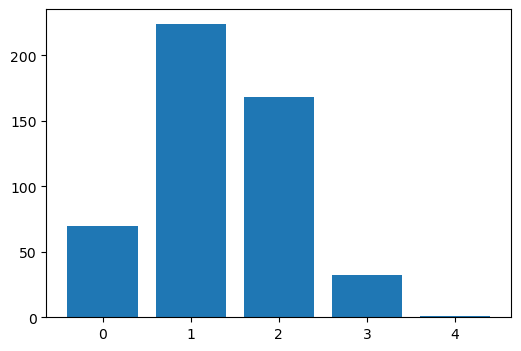

In [82]:
# Create a figure.
fig, ax = plt.subplots(figsize=(6, 4))

# Bar chart.
ax.bar(counts[0], counts[1]);

In [83]:
# Above we have simulated the overlap of four cups selected at random from twelve, and compared with all possible combinations of four cups from twelve.
# We will now simulate a similar process, but here will will simulate the guessing of four cups (The null hypothesis is that the guess is random), and compare the guess
# with a random selection of four cups that are simulated to have milk added first. 
# We willcomplete the simulation 1000000 times to get an empirical probability of a perfect match.

# Number of simulation runs.
number_simulations = 1_000_000

# Counter for the number of times the guess matches the milk in first selection.
guesses = 0

for _ in range(number_simulations):
    # Give each cup a label from 1 to 12. Note that this is just a label, and no ordering is implicit.
    # The cups are not arranged in a line or circle. They are just a set of cups.
    labels = np.arange(1, 13)

    # Select four cups at random to put milk in first.
    milk_first = np.sort(np.random.choice(labels, size = 4, replace = False))
    
    # Simulate the guessing of four cups to put milk in first.
    guess = np.sort(np.random.choice(labels, size = 4, replace = False))

    # Check if the guess matches the milk in first selection.
    if np.array_equal(guess, milk_first):
        guesses += 1

#Perfect matches: {guesses}
print(f"Perfect matches: {guesses}")

# Calculate the estimated probability of a perfect guess.
probability = guesses / number_simulations

# Show.
probability


Perfect matches: 2055


0.002055


### Interpretation

- **This probability is much smaller** than in the original Lady Tasting Tea experiment (which used 8 cups, 4 of each, leading to a 
probability of \(1/70 \approx 0.014\)).
- **A smaller probability means a more stringent test**: it is much less likely for someone to get all 4 correct by random guessing when 
choosing from 12 cups (4 milk-first).

In [84]:
# The probability that she (randomly) selects the four correct cups.
1 / 495

0.00202020202020202

### Simulation Results

If you run the simulation, the estimated probability should be very close to the theoretical value above, converging toward 0.00202 as the 
number of trials increases.

### Interpretation

- **This probability is much smaller** than in the original Lady Tasting Tea experiment (which used 8 cups, 4 of each, leading to a 
probability of \(1/70 \approx 0.014\)).
- **A smaller probability means a more stringent test**: it is much less likely for someone to get all 4 correct by random guessing when 
choosing from 12 cups (4 milk-first).

In [85]:
# The probability that she (randomly) selects at least three correct cups.
(32 + 1) / 495

0.06666666666666667

In [86]:
# Calculate probabilities for 0 to 4 correct guesses
probabilities = []
for correct in range(5):
    incorrect = 4 - correct
    ways = math.comb(4, correct) * math.comb(4, incorrect)
    probabilities.append(ways / no_combs)

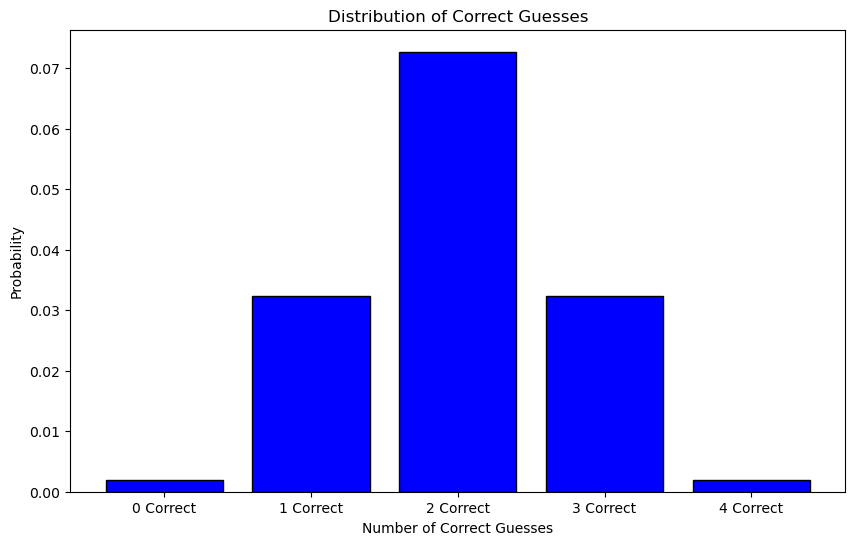

In [87]:
# Plot the distribution
labels = [f"{i} Correct" for i in range(5)]
plt.figure(figsize=(10, 6))
plt.bar(labels, probabilities, color='blue', edgecolor='black')
plt.xlabel("Number of Correct Guesses")
plt.ylabel("Probability")
plt.title("Distribution of Correct Guesses")
plt.show()

### Discussion: p-value Threshold

In hypothesis testing, the p-value represents the probability of observing a result as extreme as the experiment, assuming the null hypothesis 
(guessing) is true.

- In the original design, the probability of perfect guessing was about 1.4%. A result with p < 0.05 (5%) is usually considered statistically 
significant.
- In the extended design, the probability is 0.2%, so observing a perfect score is **much more significant**.
- **Implication:** You might consider relaxing the p-value threshold (e.g., using p < 0.01 instead of p < 0.05), since the experiment is now 
more stringent. However, using the standard 0.05 threshold is still valid and will be even more convincing.

**Conclusion:**  
Extending the number of cups makes it much less likely to get all correct by chance, making the test more powerful. The probability of a 
perfect guess drops below typical significance thresholds, so any participant achieving this would provide **extremely strong evidence** of 
genuine discrimination ability.


### Problem 2: Normal Distribution

>Generate 100,000 samples of size 10 from the standard normal distribution. For each sample, compute the standard deviation with ddof=1 (sample SD) and with ddof=0 (population SD). Plot histograms of both sets of values on the same axes with transparency. Describe the differences you see. Explain how you expect these differences to change if the sample size is increased.

# End